In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split  # 用于将数据集分割为训练集和测试集
from sklearn.preprocessing import StandardScaler  # 数据标准化工具，将特征缩放到相同尺度
from sklearn.linear_model import LinearRegression  # 线性回归模型，用于建立预测模型
from sklearn.metrics import mean_squared_error, r2_score # 模型评估指标，衡量预测性能
data = pd.read_csv("D:\\Project\\AI_learning\\housing.csv")
#分离特征（输入）和目标变量（输出）
X = data.drop('median_house_value', axis=1) # 创建特征矩阵 X（输入变量）
y = data['median_house_value'] # 创建目标向量 y（输出变量）
# 处理分类特征
if 'ocean_proximity' in X.columns:
    X = pd.get_dummies(X, columns=['ocean_proximity']) # get_dummies把文字转成数字：每个选项变成一列，有就是1，没有就是0
# 填充缺失值
X = X.fillna(X.median()) # fillna用中位数填上空值
# 划分数据集：把数据分成训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 数据标准化：把数据调到同一个尺度
scaler = StandardScaler()
# fit：计算训练集的平均值和标准差
# transform：用计算出的值转换训练集
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# 训练模型
model = LinearRegression()
model.fit(X_train, y_train)
# 预测和评估
y_pred = model.predict(X_test)
print("均方误差:", round(mean_squared_error(y_test, y_pred), 2))
print("R²分数:", round(r2_score(y_test, y_pred), 4))

均方误差: 4908476721.16
R²分数: 0.6254


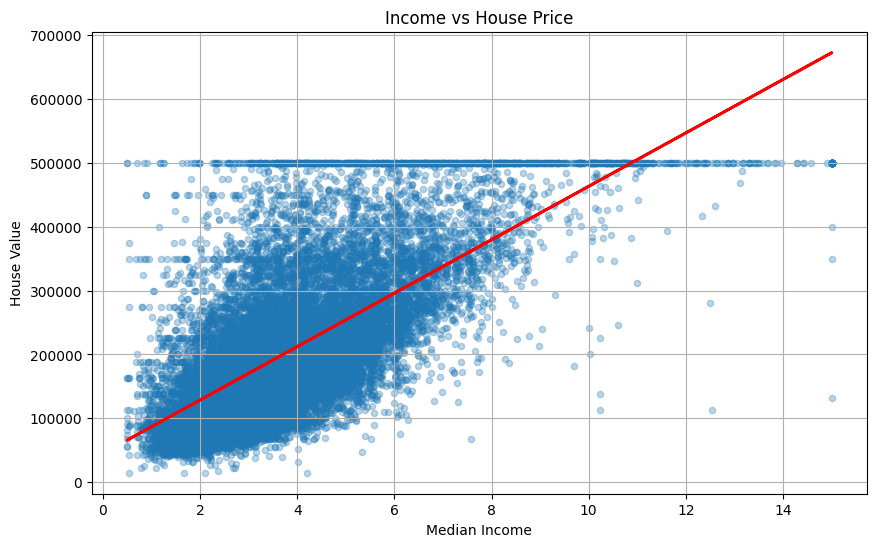

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
# 收入与房价散点图
plt.figure(figsize=(10, 6))
plt.scatter(data['median_income'], data['median_house_value'], alpha=0.3, s=20)  # 透明度30 点的大小=20像素
# 计算回归线
x = data['median_income']
y = data['median_house_value']
coef = np.polyfit(x, y, 1) # 用一次多项式（直线）拟合数据
reg_line = np.poly1d(coef) #poly1d的作用：把系数变成可计算的多项式函数
plt.plot(x, reg_line(x), 'r-', linewidth=2)
plt.title('Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.grid(True)
plt.show()

In [38]:
print("定义梯度下降回归器类")
class 梯度下降回归器:
    """
    使用梯度下降算法实现线性回归
    梯度下降原理：沿着损失函数的梯度方向逐步调整参数，使损失函数最小化
    """
    # 初始化方法
    def __init__(self, 学习率=0.01, 迭代次数=1000):
        """
        初始化梯度下降回归器
        """
        self.学习率 = 学习率          # 学习率参数
        self.迭代次数 = 迭代次数      # 最大迭代次数
        self.权重 = None            # 模型权重参数 w
        self.偏置 = None            # 模型偏置参数 b
        self.损失历史 = []           # 记录每次迭代的损失值
    # 训练模型方法
    def 训练(self, X, y):
        """
        使用梯度下降算法训练模型
        """
        print("开始梯度下降训练...")
        print("训练数据形状: X=" + str(X.shape) + ", y=" + str(y.shape))
        # 获取数据形状
        # X.shape返回一个元组，比如(100, 5)表示100个样本，5个特征
        样本数, 特征数 = X.shape
        # 样本数 = 训练样本的数量
        # 特征数 = 每个样本的特征数量
        # 初始化参数
        # np.zeros(特征数)创建一个长度为特征数的零向量
        self.权重 = np.zeros(特征数)
        self.偏置 = 0
        print("参数初始化完成: 权重维度=" + str(特征数) + ", 偏置=0")
        print("学习率=" + str(self.学习率) + ", 最大迭代次数=" + str(self.迭代次数))
        # 开始梯度下降迭代（核心循环）
        for 当前迭代 in range(self.迭代次数): 
            # 计算预测值
            # np.dot(X, self.权重) 计算矩阵乘法：X * w
            # 如果X是(m×n)矩阵，权重是(n×1)向量，结果是(m×1)向量
            # 加上偏置b：y_pred = Xw + b
            预测值 = np.dot(X, self.权重) + self.偏置
            # 计算预测误差
            误差 = 预测值 - y
            # 计算梯度
            # 权重梯度 dw = (1/m) * Xᵀ * error
            # X.T是X的转置矩阵
            # np.dot(X.T, 误差) 计算 Xᵀ * error
            # 除以样本数得到平均梯度
            权重梯度 = (1 / 样本数) * np.dot(X.T, 误差)
            # 偏置梯度 db = (1/m) * Σ(error)
            # np.sum(误差) 计算所有误差的总和
            # 除以样本数得到平均梯度
            偏置梯度 = (1 / 样本数) * np.sum(误差)
            # 更新参数
            # 沿着梯度反方向更新参数（因为要最小化损失）
            # 新的权重 = 旧的权重 - 学习率 × 权重梯度(偏置同理)
            self.权重 = self.权重 - self.学习率 * 权重梯度
            self.偏置 = self.偏置 - self.学习率 * 偏置梯度
            # 计算并记录损失
            损失 = np.mean(误差 ** 2)
            self.损失历史.append(损失)
            # 每100次迭代显示一次进度
            if 当前迭代 % 100 == 0:
                print("迭代 " + str(当前迭代).rjust(4) + ": 损失 = " + str(round(损失, 4)))
        # 训练完成
        print("最终损失: " + str(round(损失, 6)))
        print("训练总迭代次数: " + str(self.迭代次数))
    # 预测方法
    def 预测(self, X):
        """
        使用训练好的模型进行预测
        """
        return np.dot(X, self.权重) + self.偏置
print("梯度下降回归器类定义完成！")

定义梯度下降回归器类
梯度下降回归器类定义完成！


In [30]:
print("创建和训练梯度下降模型")
# 创建梯度下降模型实例
print("创建梯度下降模型实例...")
梯度下降模型 = 梯度下降回归器(学习率=0.01, 迭代次数=1000)
# 训练梯度下降模型
print("\n开始训练梯度下降模型...")
梯度下降模型.训练(X_train, y_train)
print("\n模型训练完成！")

创建和训练梯度下降模型
创建梯度下降模型实例...

开始训练梯度下降模型...
开始梯度下降训练...
训练数据形状: X=(16512, 13), y=(16512,)
参数初始化完成: 权重维度=13, 偏置=0
学习率=0.01, 最大迭代次数=1000
迭代    0: 损失 = 56297423231.0313
迭代  100: 损失 = 11572390712.1117
迭代  200: 损失 = 5958499792.5079
迭代  300: 损失 = 5154540803.375
迭代  400: 损失 = 5000648574.8175
迭代  500: 损失 = 4944943172.0173
迭代  600: 损失 = 4909701664.5377
迭代  700: 损失 = 4882352534.2669
迭代  800: 损失 = 4859930628.0376
迭代  900: 损失 = 4841178955.9817
最终损失: 4825452343.258808
训练总迭代次数: 1000

模型训练完成！


In [31]:
print("使用梯度下降模型进行预测")
# 使用梯度下降模型进行预测
print("使用梯度下降模型进行预测...")
梯度下降预测值 = 梯度下降模型.预测(X_test)
print("预测完成！")
print("预测值形状: " + str(梯度下降预测值.shape))
print("前5个预测值: " + str(梯度下降预测值[:5].round(2)))

使用梯度下降模型进行预测
使用梯度下降模型进行预测...
预测完成！
预测值形状: (4128,)
前5个预测值: [ 53920.76 109704.57 267641.1  273903.93 252166.64]


In [32]:
print("评估梯度下降模型性能")
# 评估梯度下降模型
print("评估梯度下降模型性能...")
# 计算均方误差
梯度下降均方误差 = mean_squared_error(y_test, 梯度下降预测值)
print("均方误差(MSE): " + str(round(梯度下降均方误差, 2)))
# 计算R平方分数
梯度下降R2分数 = r2_score(y_test, 梯度下降预测值)
print("R²分数: " + str(round(梯度下降R2分数, 4)))
# 计算平均绝对误差
梯度下降平均绝对误差 = np.mean(np.abs(y_test - 梯度下降预测值))
print("平均绝对误差(MAE): " + str(round(梯度下降平均绝对误差, 2)))
print("\n评估完成！")

评估梯度下降模型性能
评估梯度下降模型性能...
均方误差(MSE): 4974954915.95
R²分数: 0.6204
平均绝对误差(MAE): 50867.17

评估完成！


In [39]:
print("模型性能对比分析")
print("【sklearn线性回归模型】")
sklearn_MSE = mean_squared_error(y_test, y_pred)
sklearn_R2 = r2_score(y_test, y_pred)
print("均方误差(MSE): " + str(round(sklearn_MSE, 2)))
print("R²分数: " + str(round(sklearn_R2, 4)))
sklearn_MAE = np.mean(np.abs(y_test - y_pred))
print("平均绝对误差(MAE): " + str(round(sklearn_MAE, 2)))
print("\n【梯度下降模型】")
print("均方误差(MSE): " + str(round(梯度下降均方误差, 2)))
print("R²分数: " + str(round(梯度下降R2分数, 4)))
print("平均绝对误差(MAE): " + str(round(梯度下降平均绝对误差, 2)))
print("\n【对比分析】")
if 梯度下降R2分数 > sklearn_R2:
    print("梯度下降模型表现更好！")
elif 梯度下降R2分数 < sklearn_R2:
    print("sklearn线性回归模型表现更好！")
else:
    print("两个模型表现相当！")
#sklearn线性回归 = 标准答案（解析解）
#梯度下降 = 你的答案（数值解）

模型性能对比分析
【sklearn线性回归模型】
均方误差(MSE): 4908476721.16
R²分数: 0.6254
平均绝对误差(MAE): 50670.74

【梯度下降模型】
均方误差(MSE): 4974954915.95
R²分数: 0.6204
平均绝对误差(MAE): 50867.17

【对比分析】
sklearn线性回归模型表现更好！


可视化损失下降曲线
绘制损失下降曲线...


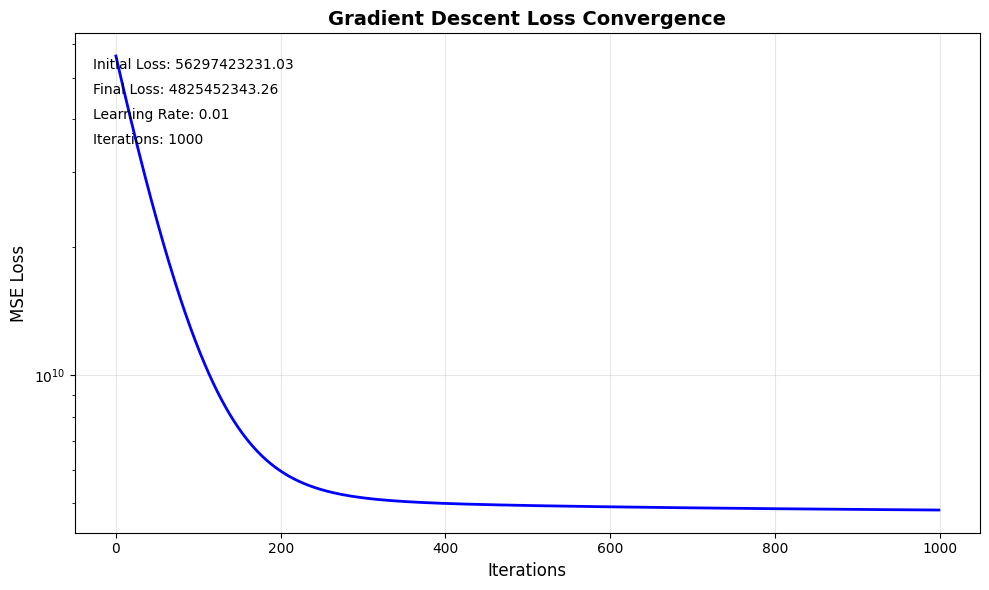

损失下降曲线显示完成！
初始损失: 56297423231.03
最终损失: 4825452343.26
学习率: 0.01
迭代次数: 1000


In [40]:
print("可视化损失下降曲线")
print("绘制损失下降曲线...")
plt.figure(figsize=(10, 6))
plt.plot(梯度下降模型.损失历史, color='blue', linewidth=2)
plt.title("Gradient Descent Loss Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # 使用对数坐标更清楚地显示损失下降
# 添加英文说明
#第一个损失值
initial_loss = round(梯度下降模型.损失历史[0], 2)
#最后一个损失值
final_loss = round(梯度下降模型.损失历史[-1], 2)
plt.text(0.02, 0.95, "Initial Loss: " + str(initial_loss), 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.02, 0.90, "Final Loss: " + str(final_loss), 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
# 0.02 - x坐标位置（相对于整个坐标轴的2%位置）
# 0.95 - y坐标位置（相对于整个坐标轴的95%位置）
# "Initial Loss: " + str(initial_loss) - 显示的文本
# transform=plt.gca().transAxes - 使用坐标轴相对坐标（0-1范围）
# fontsize=10 - 字体大小
# verticalalignment='top' - 垂直对齐方式为顶部对齐
# 显示学习率信息
learning_rate = 梯度下降模型.学习率
iterations = 梯度下降模型.迭代次数
plt.text(0.02, 0.85, f"Learning Rate: {learning_rate}", 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.02, 0.80, f"Iterations: {iterations}", 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.tight_layout()
plt.show()
print("损失下降曲线显示完成！")
print("初始损失: " + str(initial_loss))
print("最终损失: " + str(final_loss))
print("学习率: " + str(learning_rate))
print("迭代次数: " + str(iterations))

可视化预测结果对比
绘制预测结果对比图...


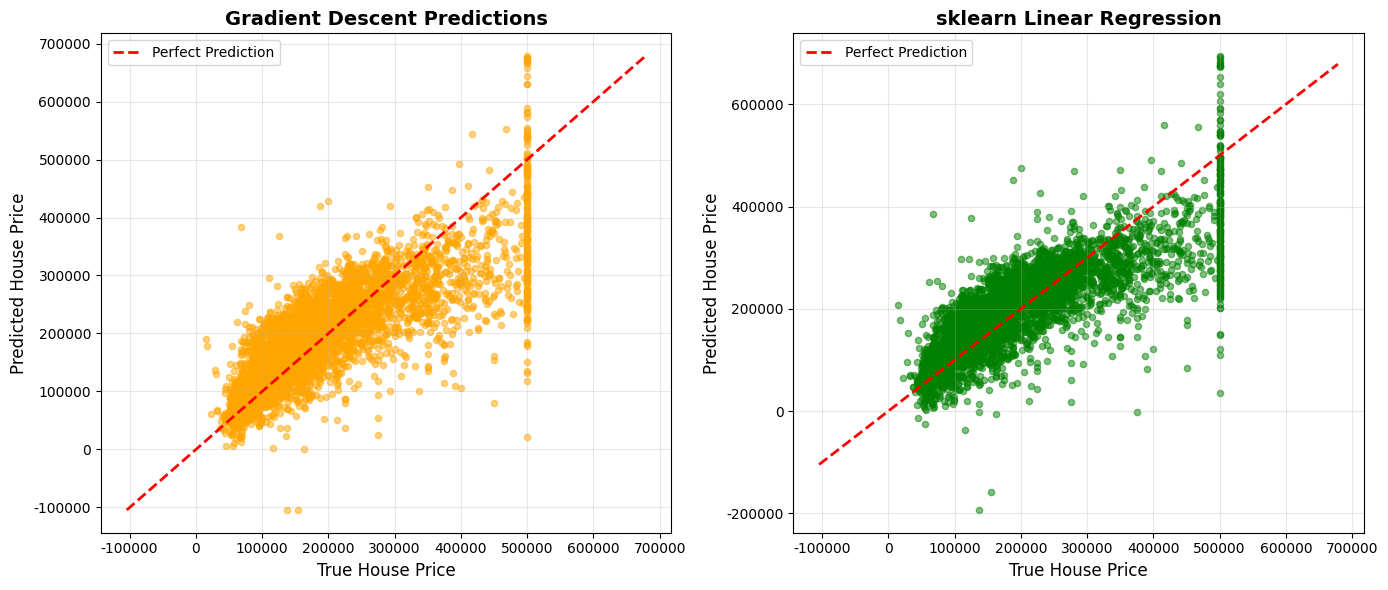

预测结果对比图显示完成！


In [41]:
print("可视化预测结果对比")
print("绘制预测结果对比图...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# 梯度下降预测结果
#axes[0]是子图一axes[1]是子图二
axes[0].scatter(y_test, 梯度下降预测值, alpha=0.5, s=20, color='orange')
最小值 = min(y_test.min(), 梯度下降预测值.min())
最大值 = max(y_test.max(), 梯度下降预测值.max())
axes[0].plot([最小值, 最大值], [最小值, 最大值], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title("Gradient Descent Predictions", fontsize=14, fontweight='bold')
axes[0].set_xlabel("True House Price", fontsize=12)
axes[0].set_ylabel("Predicted House Price", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
# sklearn预测结果
axes[1].scatter(y_test, y_pred, alpha=0.5, s=20, color='green')
axes[1].plot([最小值, 最大值], [最小值, 最大值], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title("sklearn Linear Regression", fontsize=14, fontweight='bold')
axes[1].set_xlabel("True House Price", fontsize=12)
axes[1].set_ylabel("Predicted House Price", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
print("预测结果对比图显示完成！")

In [42]:
print("特征权重分析")
# 获取特征名称
特征名称列表 = X.columns.tolist()
print("总特征数量: " + str(len(特征名称列表)))
# 获取模型权重
sklearn权重 = model.coef_
sklearn偏置 = model.intercept_
梯度下降权重 = 梯度下降模型.权重
梯度下降偏置 = 梯度下降模型.偏置
# 创建权重对比表格
print("\n【权重对比表（前10个特征）】")
权重对比表 = pd.DataFrame({
    'Feature': 特征名称列表 + ['Bias'],
    'sklearn_Weight': list(sklearn权重) + [sklearn偏置],
    'GD_Weight': list(梯度下降权重) + [梯度下降偏置],
    'Weight_Diff': list(sklearn权重 - 梯度下降权重) + [sklearn偏置 - 梯度下降偏置]
})
print(权重对比表.head(11).to_string())
print("\n【权重分析】")
print("1. 权重值表示特征对房价的影响")
print("2. 正权重：特征值增加，房价预测增加")
print("3. 负权重：特征值增加，房价预测减少")

特征权重分析
总特征数量: 13

【权重对比表（前10个特征）】
                      Feature  sklearn_Weight     GD_Weight   Weight_Diff
0                   longitude   -53826.648016 -16853.761820 -36972.886196
1                    latitude   -54415.696144 -15543.909771 -38871.786373
2          housing_median_age    13889.866189  14626.993759   -737.127570
3                 total_rooms   -13094.251162   4709.484419 -17803.735581
4              total_bedrooms    43068.181842  18824.827355  24243.354486
5                  population   -43403.432427 -32730.477089 -10672.955338
6                  households    18382.196324  15650.813319   2731.383005
7               median_income    75167.774766  71966.979826   3200.794940
8   ocean_proximity_<1H OCEAN     6424.355629   9545.370670  -3121.015042
9      ocean_proximity_INLAND   -12492.687560 -21543.848271   9051.160712
10     ocean_proximity_ISLAND     2319.634266   2708.757640   -389.123374

【权重分析】
1. 权重值表示特征对房价的影响
2. 正权重：特征值增加，房价预测增加
3. 负权重：特征值增加，房价预测减少


可视化权重对比
生成权重对比柱状图...


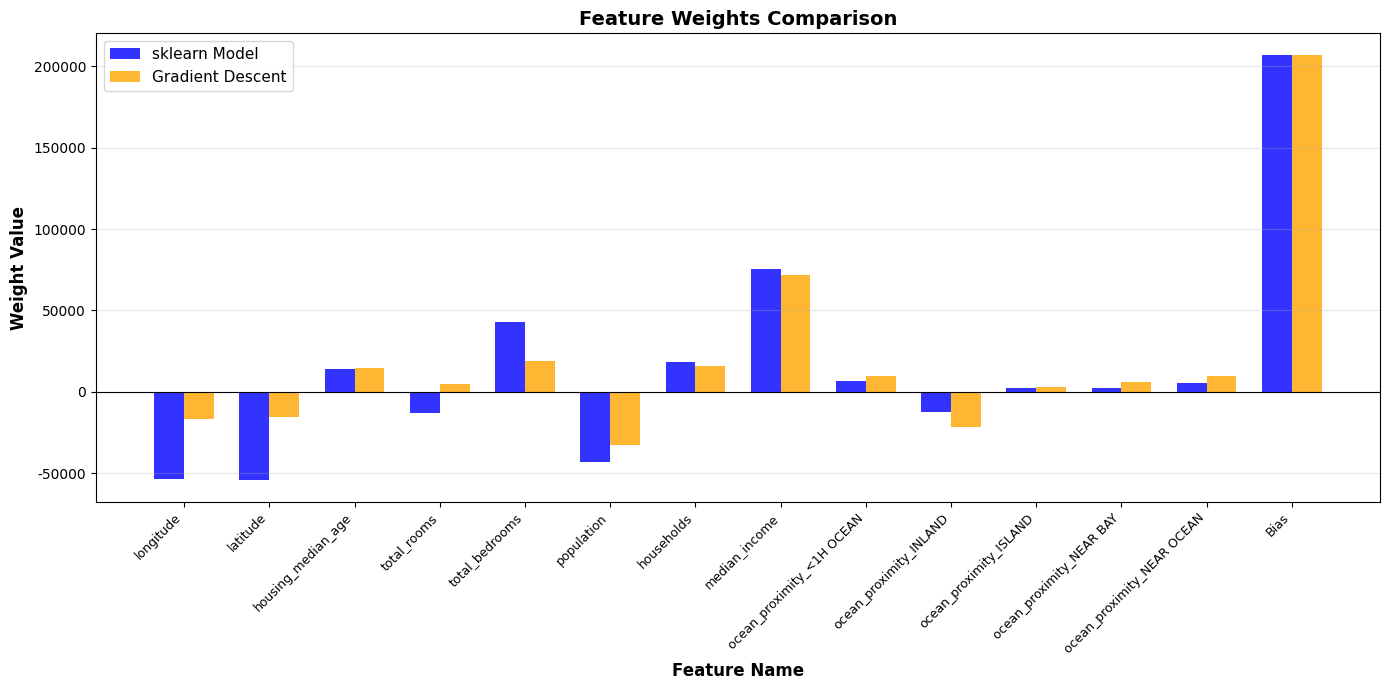

权重对比图显示完成！


In [36]:
print("可视化权重对比")
print("生成权重对比柱状图...")
plt.figure(figsize=(14, 7))
位置 = np.arange(len(特征名称列表) + 1)
柱宽 = 0.35
# 绘制柱状图
plt.bar(位置 - 柱宽/2, 权重对比表['sklearn_Weight'], 
        柱宽, label='sklearn Model', alpha=0.8, color='blue')
plt.bar(位置 + 柱宽/2, 权重对比表['GD_Weight'], 
        柱宽, label='Gradient Descent', alpha=0.8, color='orange')
plt.xlabel('Feature Name', fontsize=12, fontweight='bold')
plt.ylabel('Weight Value', fontsize=12, fontweight='bold')
plt.title('Feature Weights Comparison', fontsize=14, fontweight='bold')
plt.xticks(位置, 权重对比表['Feature'], rotation=45, ha='right', fontsize=9)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print("权重对比图显示完成！")

In [37]:
print("详细预测结果对比")
print("前10个样本的详细预测结果对比：")
样本对比表 = pd.DataFrame({
    'Sample_ID': range(1, 11),
    'True_Price': y_test.values[:10],
    'sklearn_Pred': y_pred[:10],
    'GD_Pred': 梯度下降预测值[:10],
    'sklearn_Error': y_test.values[:10] - y_pred[:10],
    'GD_Error': y_test.values[:10] - 梯度下降预测值[:10],
    'sklearn_RE(%)': np.abs((y_test.values[:10] - y_pred[:10]) / y_test.values[:10]) * 100,
    'GD_RE(%)': np.abs((y_test.values[:10] - 梯度下降预测值[:10]) / y_test.values[:10]) * 100
})
print(样本对比表.round(2).to_string())
print("\n【总结统计】")
print("sklearn模型平均相对误差: " + str(round(样本对比表['sklearn_RE(%)'].mean(), 1)) + "%")
print("梯度下降模型平均相对误差: " + str(round(样本对比表['GD_RE(%)'].mean(), 1)) + "%")
print("\n梯度下降算法实现完成！")

详细预测结果对比
前10个样本的详细预测结果对比：
   Sample_ID  True_Price  sklearn_Pred    GD_Pred  sklearn_Error   GD_Error  sklearn_RE(%)  GD_RE(%)
0          1     47700.0      54055.45   53920.76       -6355.45   -6220.76          13.32     13.04
1          2     45800.0     124225.34  109704.57      -78425.34  -63904.57         171.23    139.53
2          3    500001.0     255489.38  267641.10      244511.62  232359.90          48.90     46.47
3          4    218600.0     268002.43  273903.93      -49402.43  -55303.93          22.60     25.30
4          5    278000.0     262769.43  252166.64       15230.57   25833.36           5.48      9.29
5          6    158700.0     139606.30  153313.08       19093.70    5386.92          12.03      3.39
6          7    198200.0     290665.42  283113.59      -92465.42  -84913.59          46.65     42.84
7          8    157500.0     228264.88  225140.62      -70764.88  -67640.62          44.93     42.95
8          9    340000.0     256506.79  250488.42       83493.21 